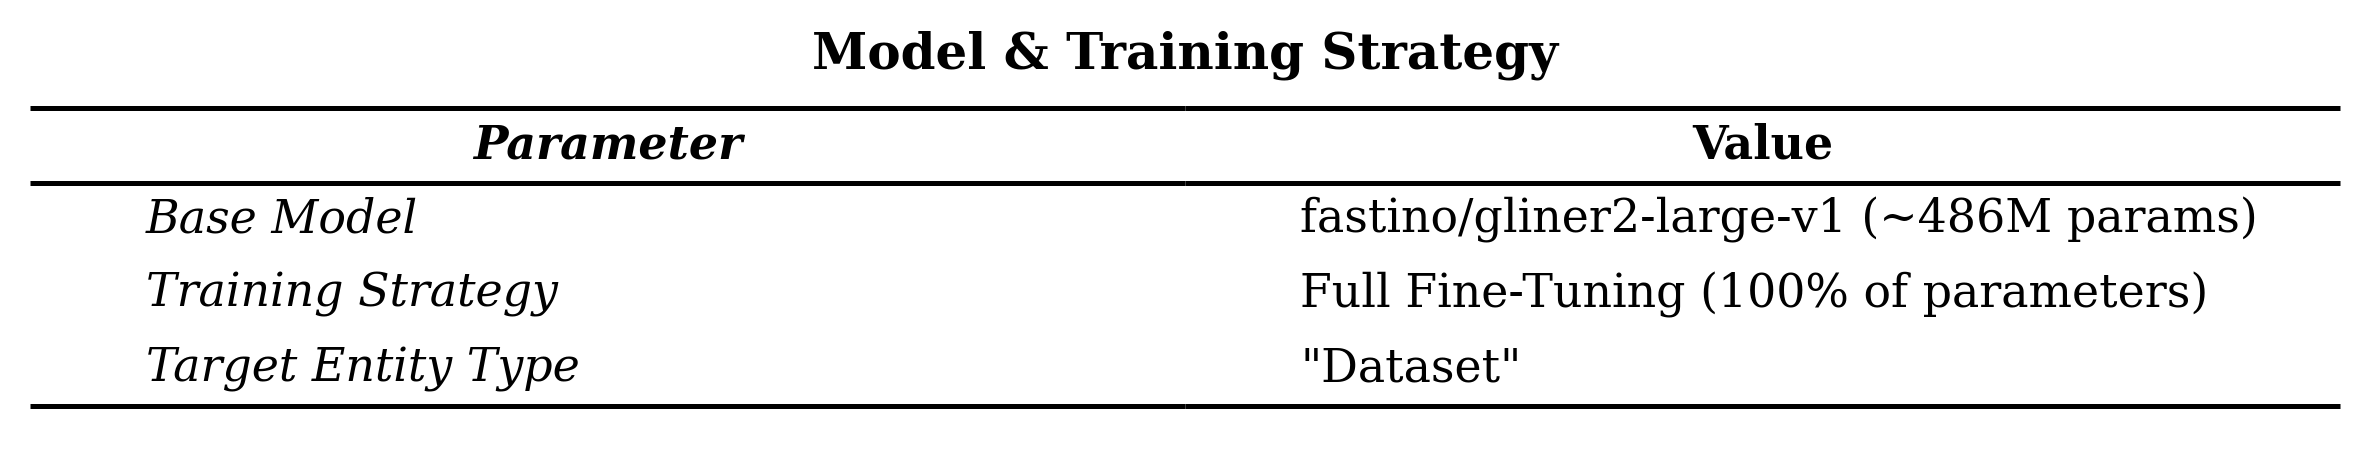

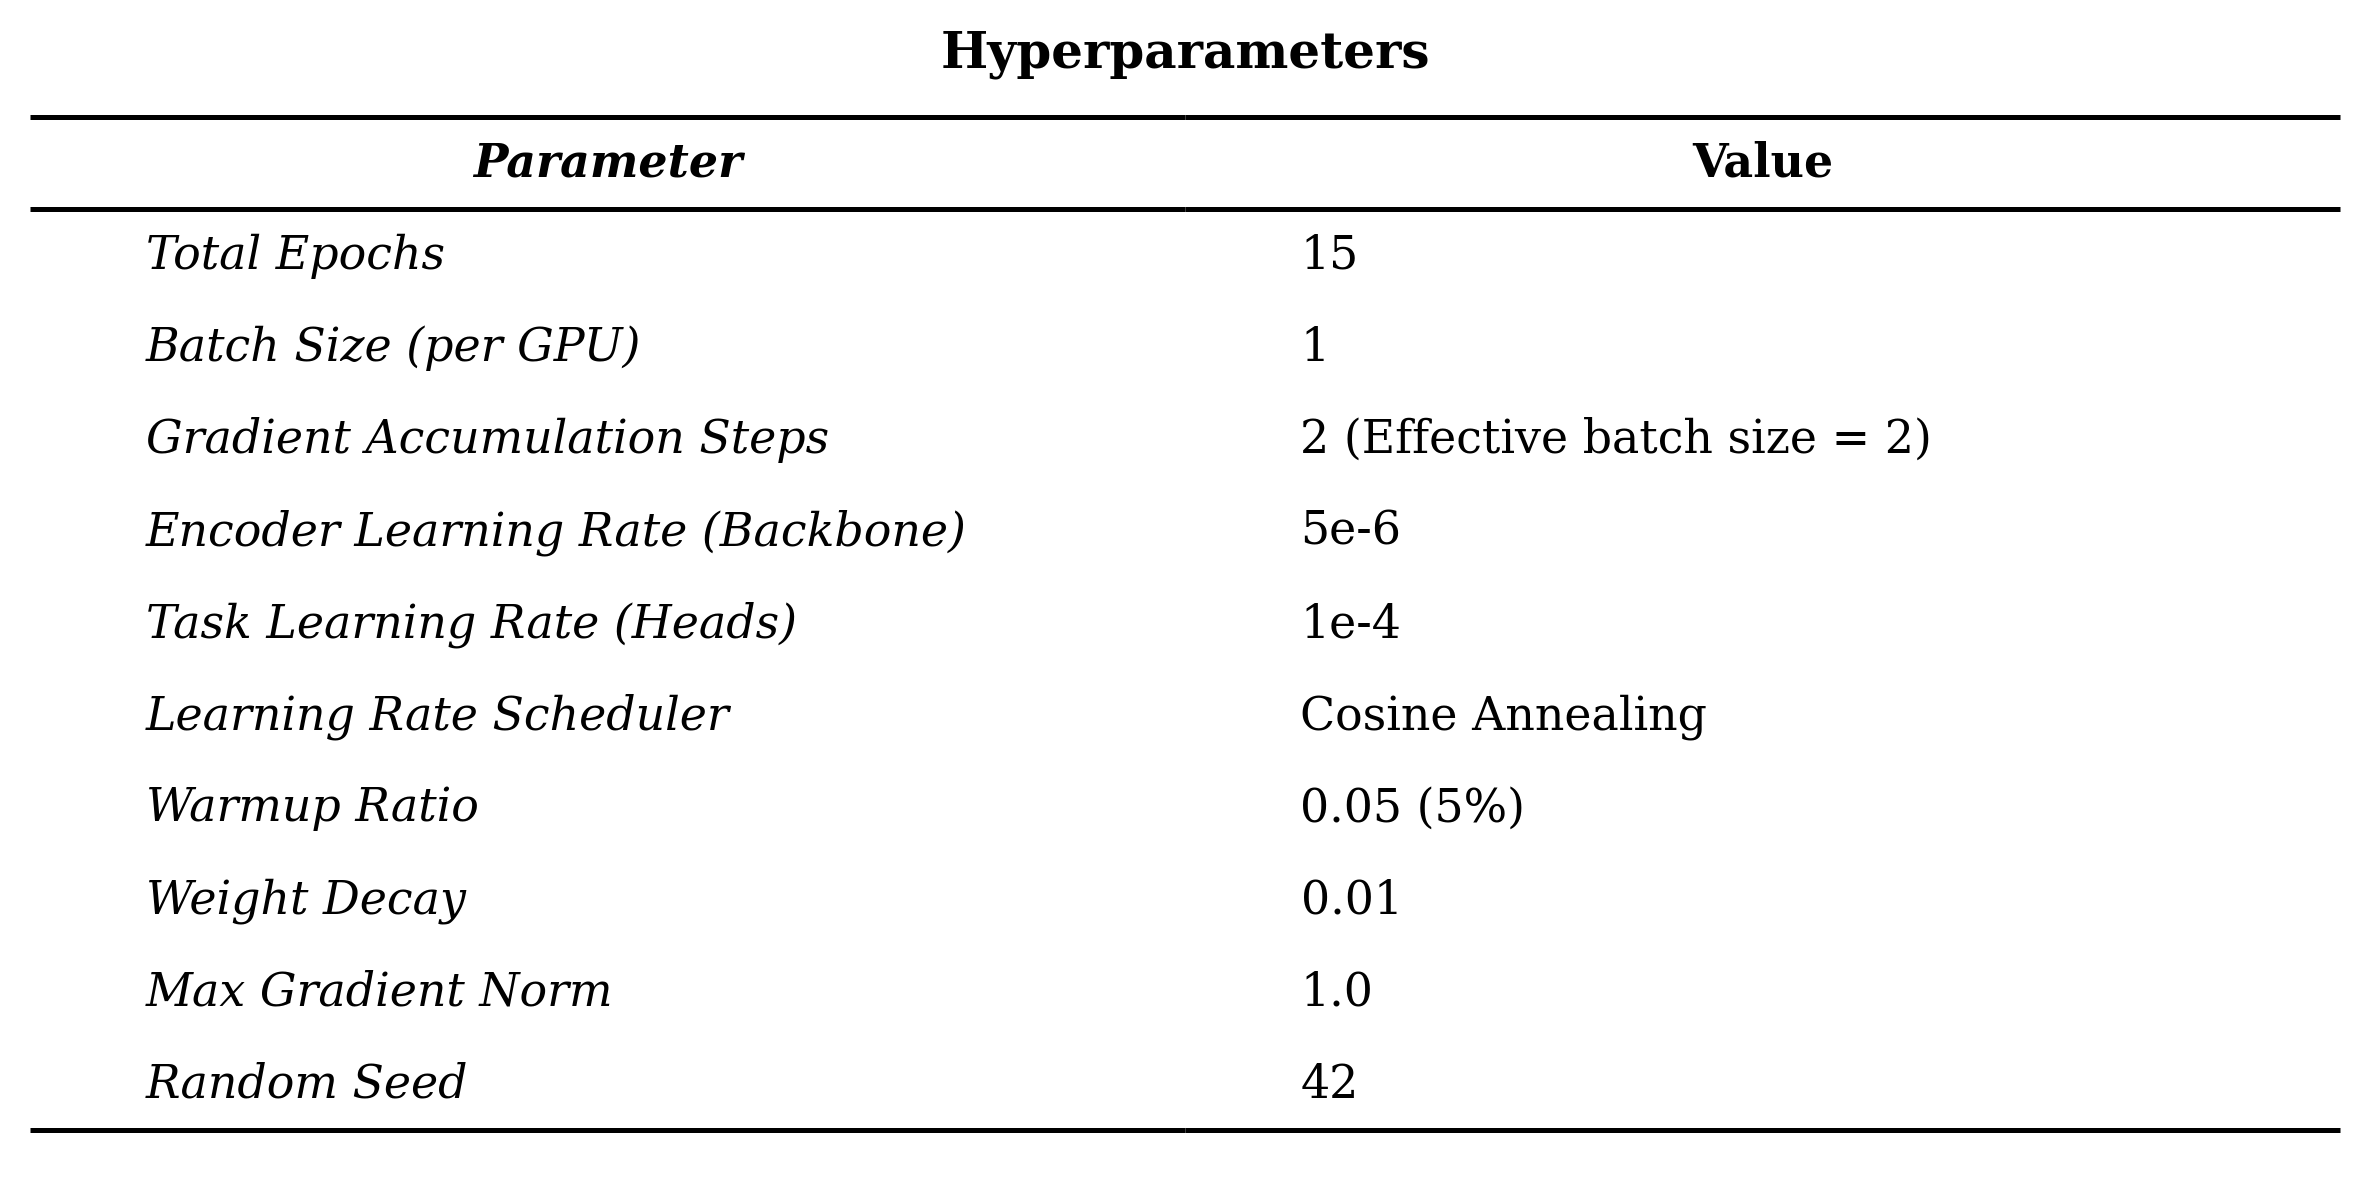

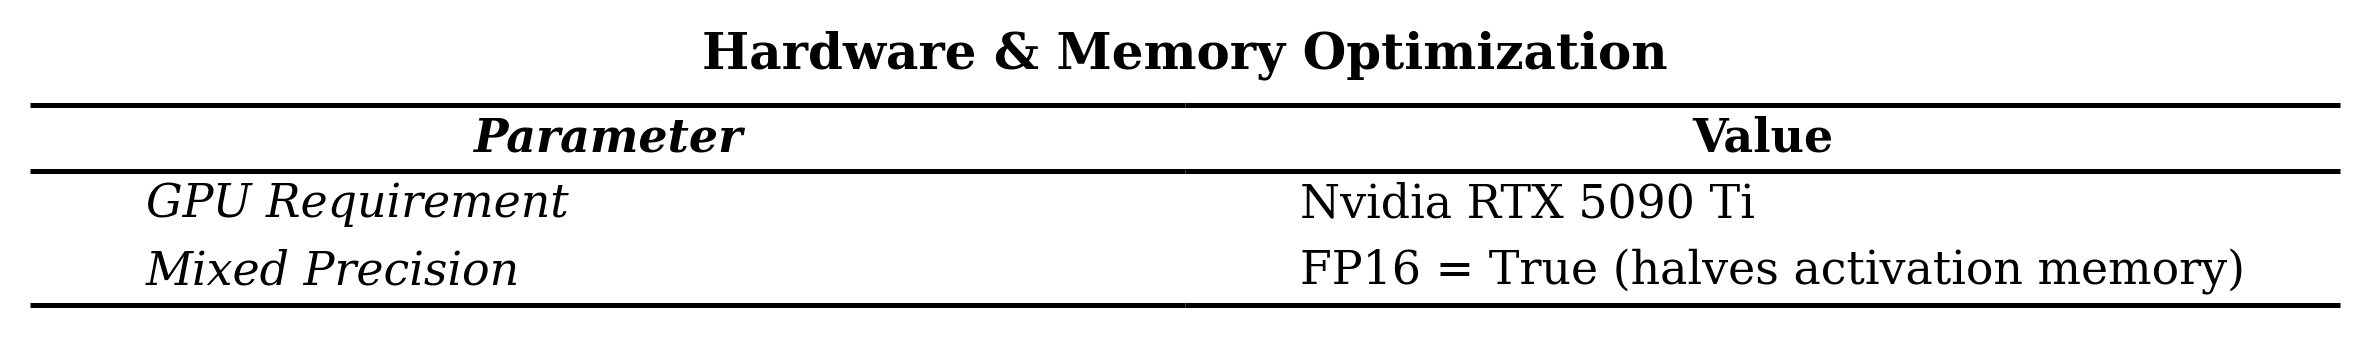

In [11]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

# Set font to emulate a publication-ready look (serif)
mpl.rcParams['font.family'] = 'serif'

# Define the data separated by category
tables = {
    "Model & Training Strategy": [
        ["Base Model", "fastino/gliner2-large-v1 (~486M params)"],
        ["Training Strategy", "Full Fine-Tuning (100% of parameters)"],
        ["Target Entity Type", '"Dataset"']
    ],
    "Hyperparameters": [
        ["Total Epochs", "15"],
        ["Batch Size (per GPU)", "1"],
        ["Gradient Accumulation Steps", "2 (Effective batch size = 2)"],
        ["Encoder Learning Rate (Backbone)", "5e-6"],
        ["Task Learning Rate (Heads)", "1e-4"],
        ["Learning Rate Scheduler", "Cosine Annealing"],
        ["Warmup Ratio", "0.05 (5%)"],
        ["Weight Decay", "0.01"],
        ["Max Gradient Norm", "1.0"],
        ["Random Seed", "42"]
    ],
    "Hardware & Memory Optimization": [
        ["GPU Requirement", "Nvidia RTX 5090 Ti"],
        ["Mixed Precision", "FP16 = True (halves activation memory)"]
    ]
}

columns = ["Parameter", "Value"]

# Create plots directory if it doesn't exist
os.makedirs("plots", exist_ok=True)

for title, data in tables.items():
    # Adjust figure height based on the number of rows (made smaller to reduce gap)
    fig, ax = plt.subplots(figsize=(8, len(data) * 0.35 + 0.6), dpi=300)
    ax.axis('off')

    # Create the table
    table = ax.table(cellText=data, colLabels=columns, loc='center', cellLoc='left')

    # Style the table for publication (black and white, horizontal lines only)
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.0, 1.6)

    # Format cells: remove vertical borders, add standard academic horizontal lines
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('black')
        cell.set_linewidth(0) # Remove default borders
        
        # Add horizontal lines
        if row == 0:
            # Top and bottom borders for the header
            cell.set_text_props(weight='bold')
            cell.visible_edges = 'BT' 
            cell.set_linewidth(1.2)
        elif row == len(data):
            # Bottom border for the last row
            cell.visible_edges = 'B'
            cell.set_linewidth(1.2)
        else:
            # Inner rows (optional light lines or none, standard is none)
            cell.visible_edges = ''
            
        # Add slight padding
        if col == 0:
            cell.pad = 0.05
            cell.set_text_props(style='italic') # Parameter names in italic

    # Reduced pad=0 to bring title closer to the table
    plt.title(title, fontsize=12, fontweight='bold', pad=0)
    
    # Save the figure as a high-res PDF and PNG
    filename = title.replace(" ", "_").replace("&", "and").lower()
    filepath_base = os.path.join("plots", filename)
    plt.tight_layout()
    plt.savefig(f"{filepath_base}.png", dpi=300, bbox_inches='tight', transparent=True)
    plt.savefig(f"{filepath_base}.pdf", bbox_inches='tight')
    
    plt.show()